**Autism Spectrum Disorder (ASD)**

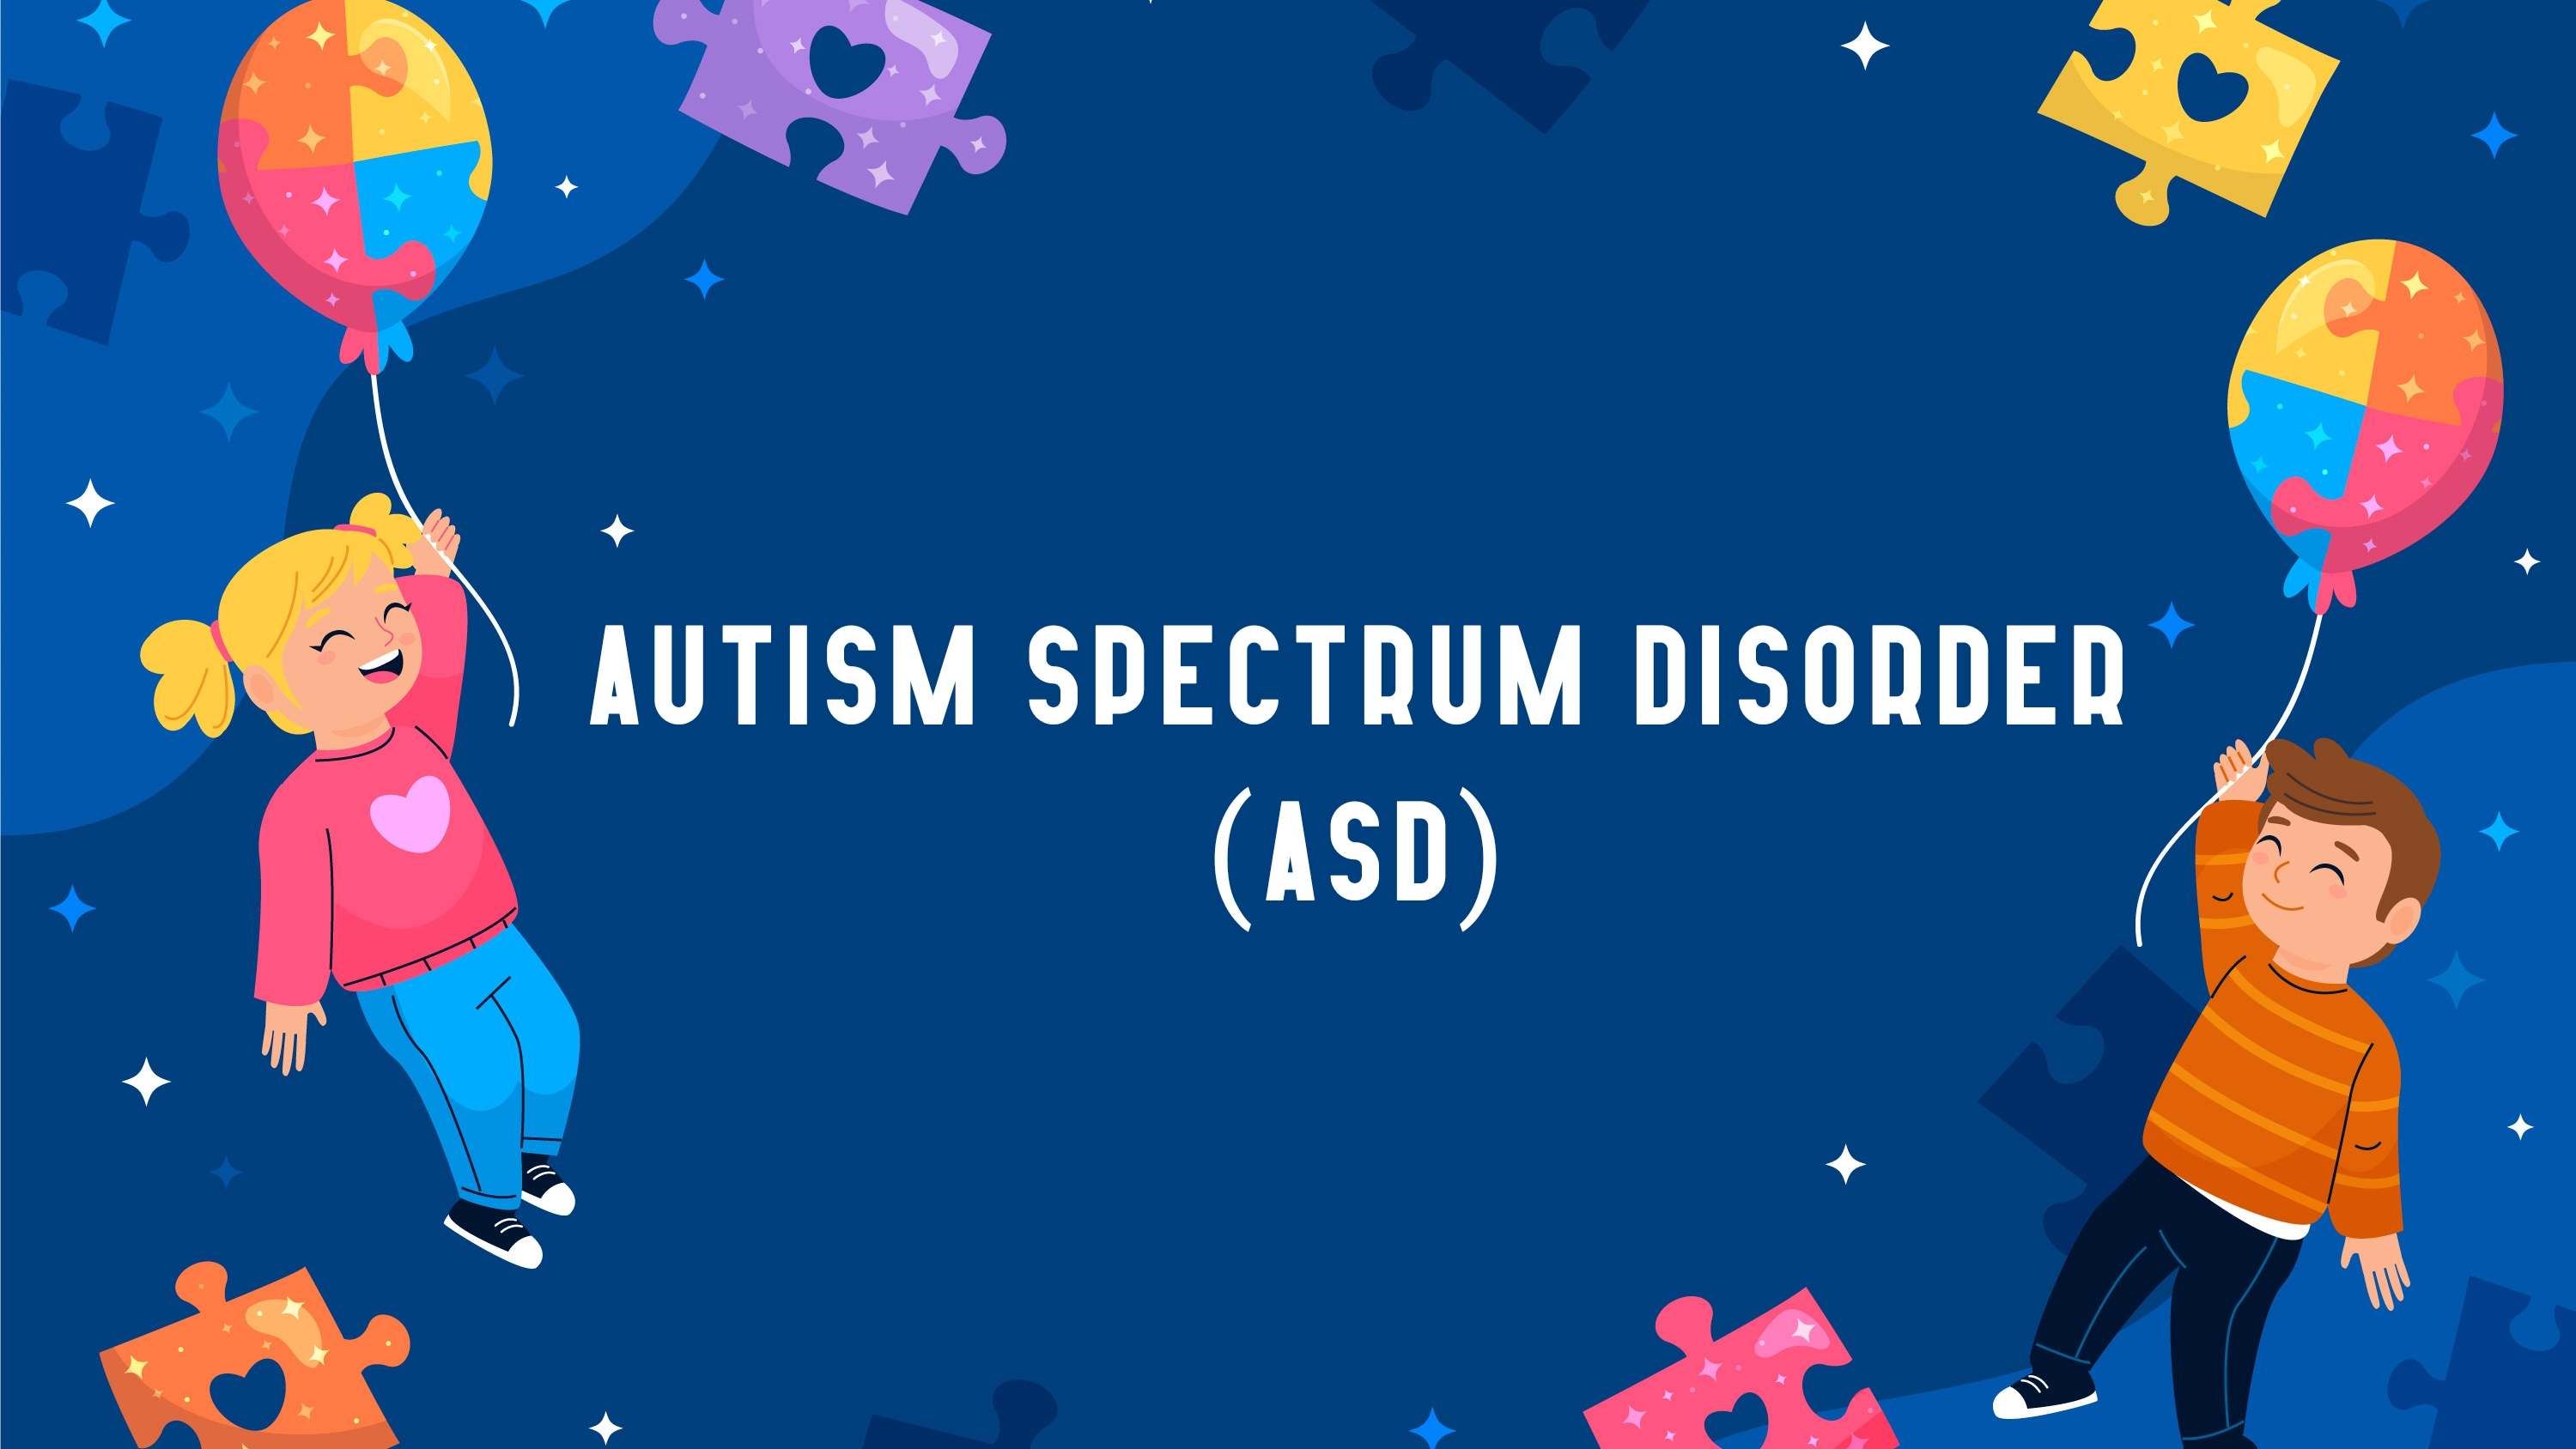

**IMPORT NECESSARY LIBRARIES**

In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import math
from sklearn.preprocessing import LabelEncoder
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import precision_recall_curve, auc, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

**READ DATASET**

In [4]:
df = pd.read_csv('C:\\Users\\Indhumathi\\asd project\\ASDD.csv')

In [5]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


**DISPLAYING SHAPE & TYPES OF THE DATASET**

In [6]:
print(df.shape)

(704, 21)


In [7]:
df.dtypes

A1_Score             int64
A2_Score             int64
A3_Score             int64
A4_Score             int64
A5_Score             int64
A6_Score             int64
A7_Score             int64
A8_Score             int64
A9_Score             int64
A10_Score            int64
age                float64
gender              object
ethnicity           object
jundice             object
austim              object
contry_of_res       object
used_app_before     object
result             float64
age_desc            object
relation            object
Class/ASD           object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

In [9]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                2
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

**MISSING VALUE FILLED BY MEAN VALUE**

In [10]:
nulcol = ['age']

In [11]:
for i in nulcol:
    mean = df[i].mean()
    df[i].replace(np.nan, mean, inplace=True)

In [12]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

**DROPPING THE IRRELEVANT ATTRIBUTES**

In [13]:
df.drop(['contry_of_res','used_app_before','age_desc','result'], axis = 1, inplace = True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   A1_Score   704 non-null    int64  
 1   A2_Score   704 non-null    int64  
 2   A3_Score   704 non-null    int64  
 3   A4_Score   704 non-null    int64  
 4   A5_Score   704 non-null    int64  
 5   A6_Score   704 non-null    int64  
 6   A7_Score   704 non-null    int64  
 7   A8_Score   704 non-null    int64  
 8   A9_Score   704 non-null    int64  
 9   A10_Score  704 non-null    int64  
 10  age        704 non-null    float64
 11  gender     704 non-null    object 
 12  ethnicity  704 non-null    object 
 13  jundice    704 non-null    object 
 14  austim     704 non-null    object 
 15  relation   704 non-null    object 
 16  Class/ASD  704 non-null    object 
dtypes: float64(1), int64(10), object(6)
memory usage: 93.6+ KB


**ELPLORATORY DATA ANALYSIS (EDA)**

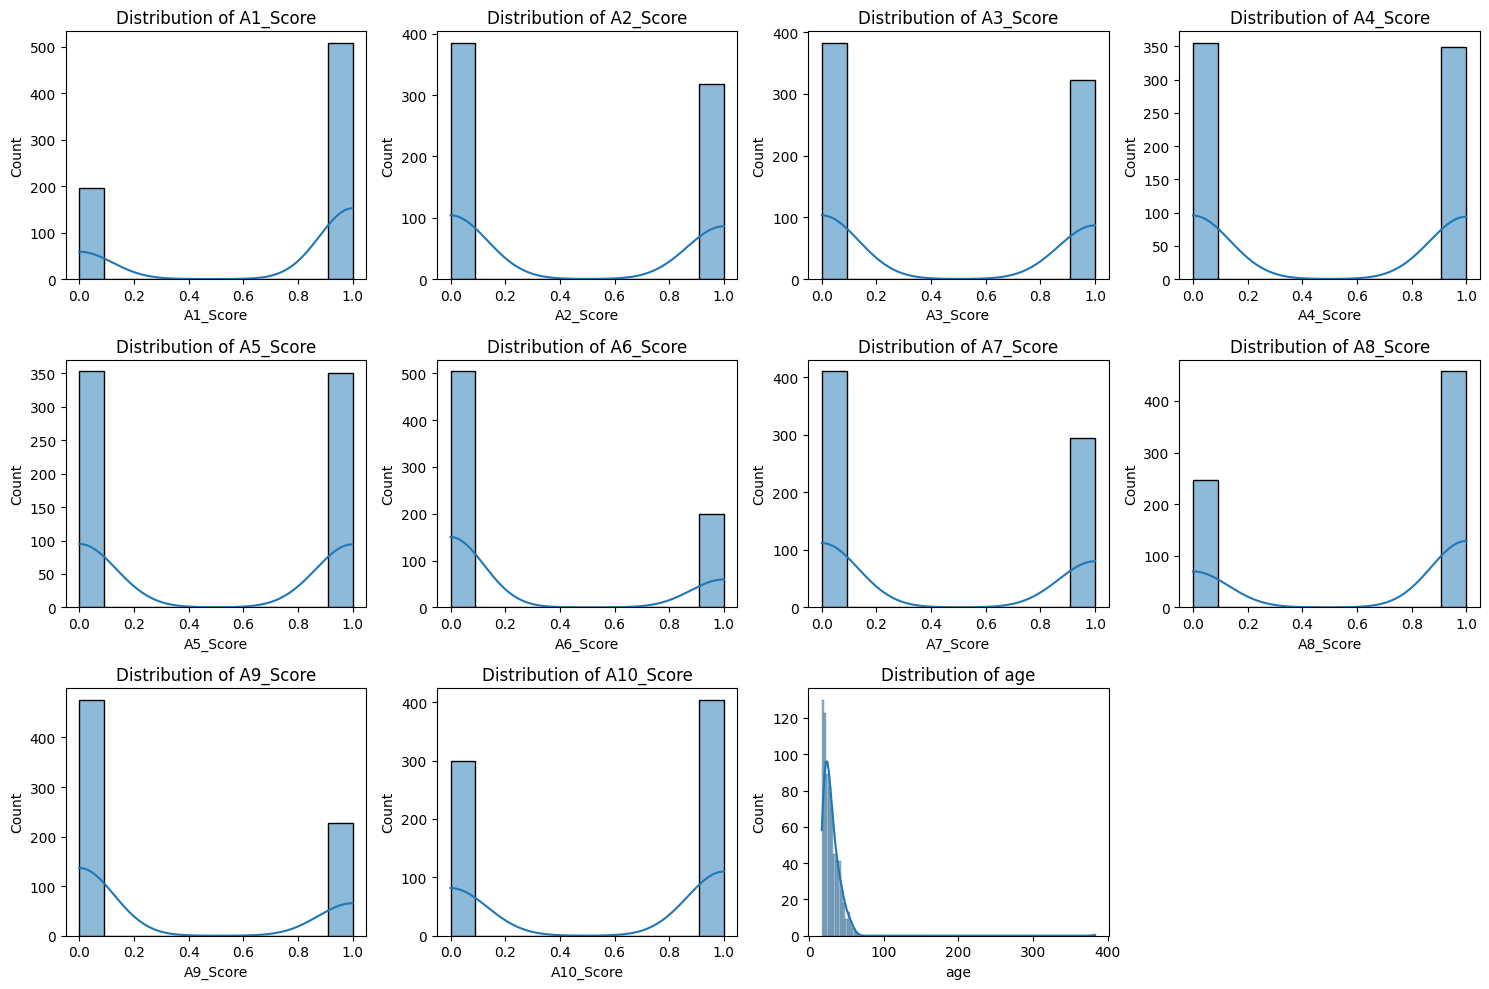

In [15]:
plt.figure(figsize=(15, 10))

numeric_features = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age']


for i, feature in enumerate(numeric_features):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

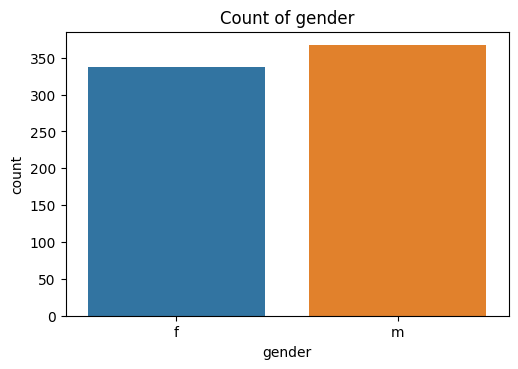

In [16]:
plt.figure(figsize=(15, 10))

categorical_features = ['gender']

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i + 7)
    sns.countplot(data=df, x=feature, hue='gender')
    plt.title(f'Count of {feature}')
plt.tight_layout()
plt.show()

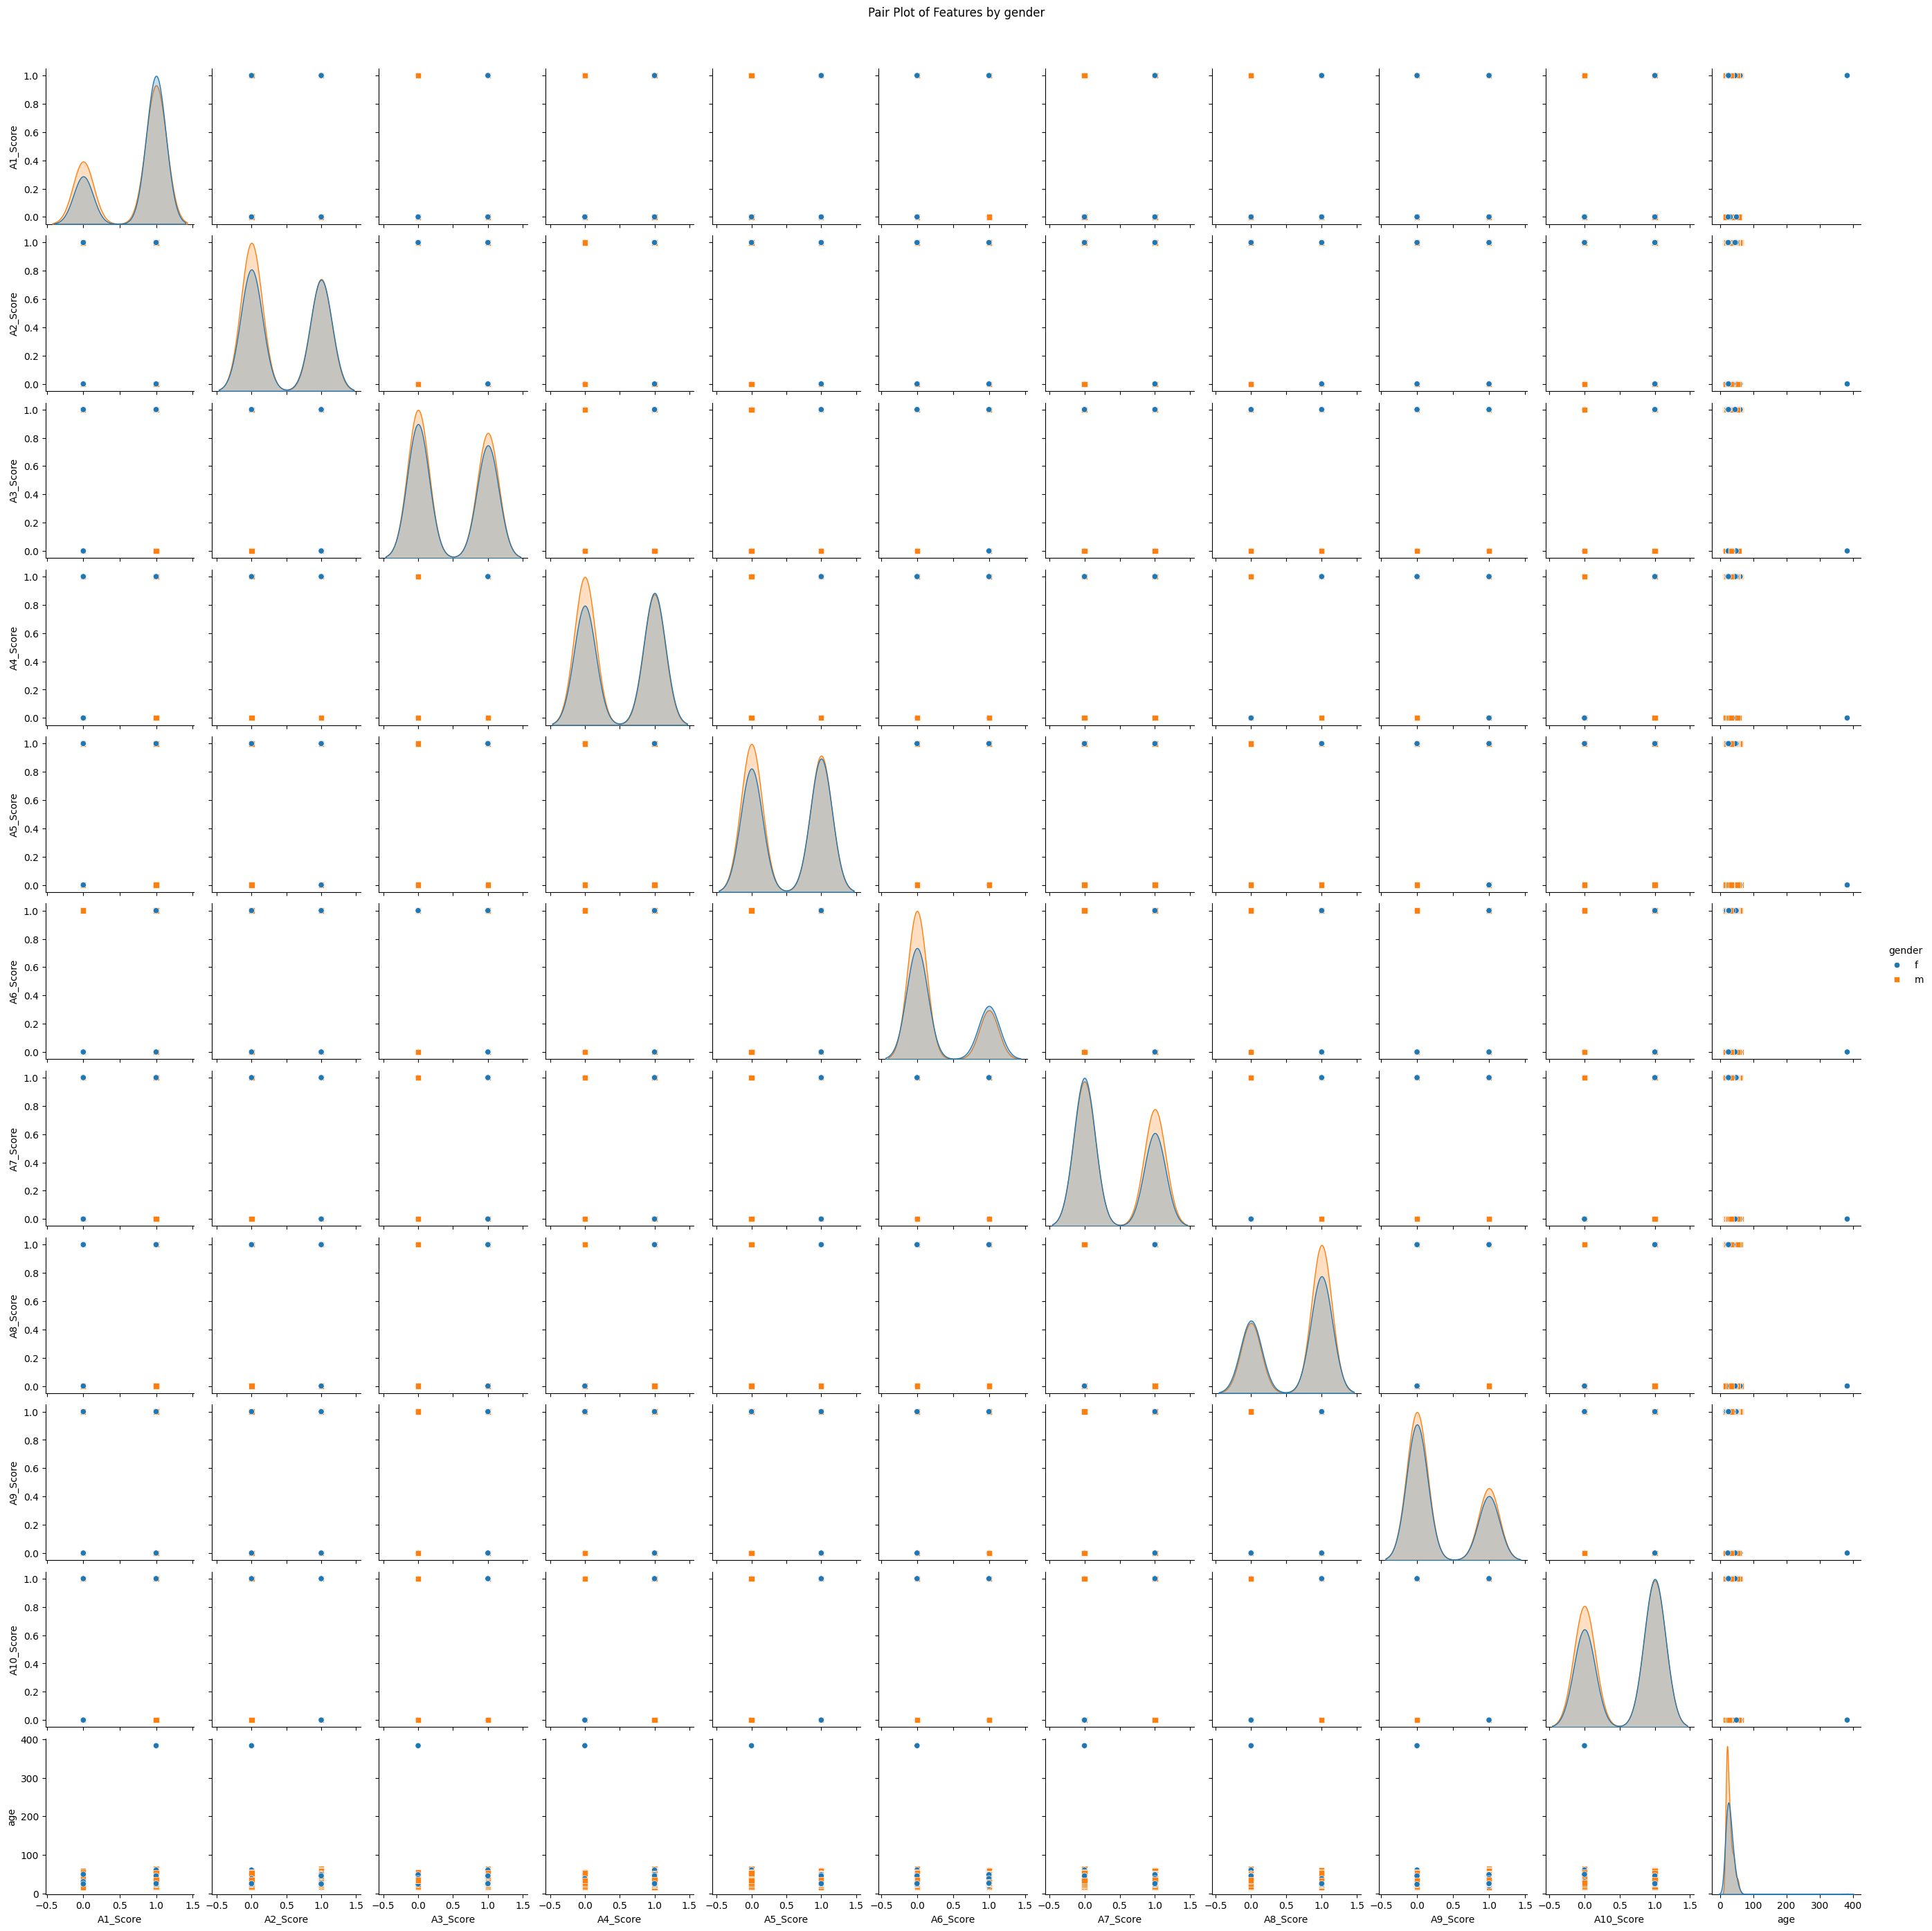

In [17]:
selected_features = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score',
                     'A9_Score','A10_Score','age', 'gender']

sns.pairplot(df[selected_features], hue='gender', markers=['o', 's', 'D'],
             diag_kind='kde', height=2.5)
plt.suptitle('Pair Plot of Features by gender', y=1.02)
plt.show()

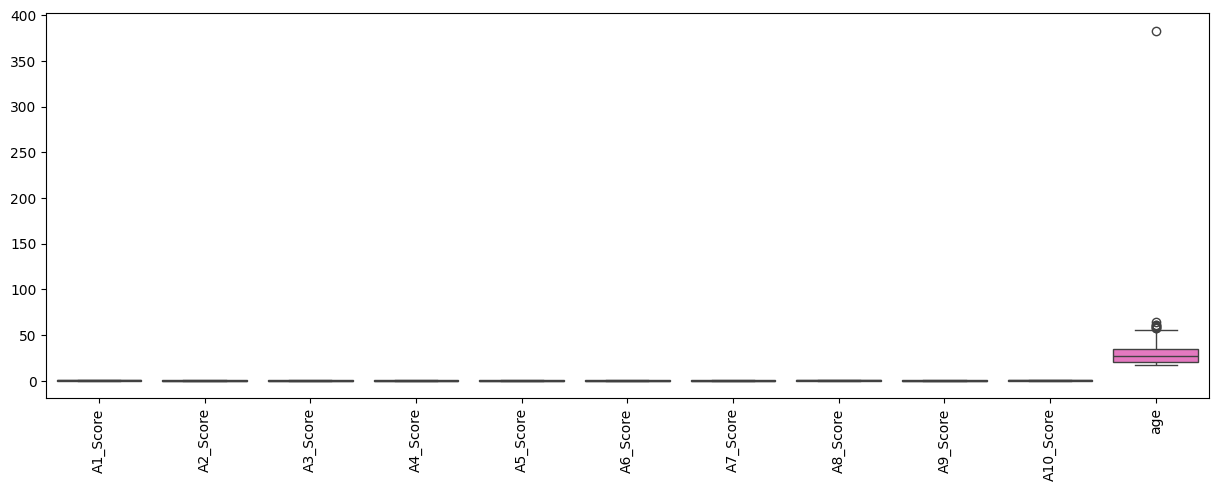

In [18]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df)
plt.xticks(rotation=90, fontsize=10)
plt.show()

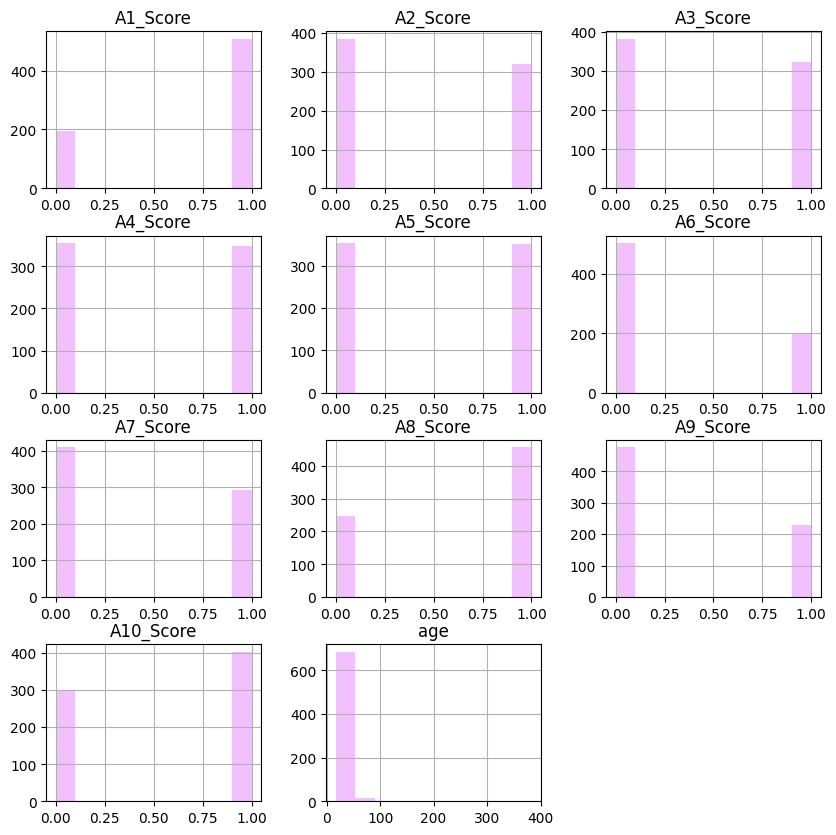

In [19]:
hist_plot = df.hist(figsize = (10,10), color = "#f2c0ff")

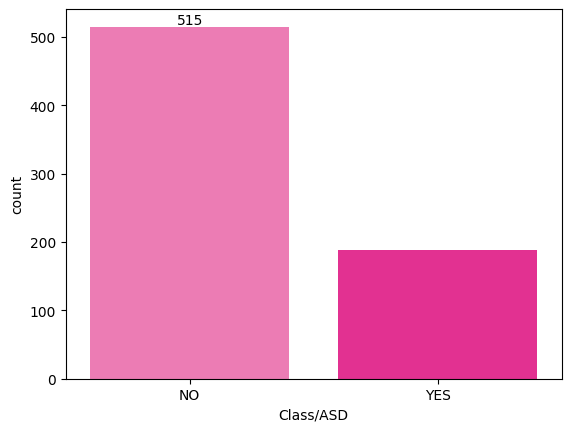

In [20]:
colors=["#FF69B4","#FF1493", "#C71585"]
ax = sns.countplot(data= df, x="Class/ASD", palette=colors)
ax.bar_label(ax.containers[0])
plt.show()

**CATEGORICAL DATA'S CONVERTED INTO NUMERICAL VALUES USING ENCODING TECHNIQUE**

In [21]:
df["gender"].unique()

array(['f', 'm'], dtype=object)

In [22]:
df["jundice"].unique()

array(['no', 'yes'], dtype=object)

In [23]:
df["austim"].unique()

array(['no', 'yes'], dtype=object)

In [24]:
df["Class/ASD"].unique()

array(['NO', 'YES'], dtype=object)

In [25]:
df['gender'] = df['gender'].map({'f': 0, 'm': 1})

In [26]:
df['jundice'] = df['jundice'].map({'no': 0, 'yes': 1})

In [27]:
df['austim'] = df['austim'].map({'no': 0, 'yes': 1})

In [28]:
df['Class/ASD'] = df['Class/ASD'].map({'NO': 0, 'YES': 1})

In [29]:
df["ethnicity"].unique()

array(['White-European', 'Latino', '?', 'Others', 'Black', 'Asian',
       'Middle Eastern ', 'Pasifika', 'South Asian', 'Hispanic',
       'Turkish', 'others'], dtype=object)

In [30]:
df["relation"].unique()

array(['Self', 'Parent', '?', 'Health care professional', 'Relative',
       'Others'], dtype=object)

In [31]:
label_encoder = LabelEncoder()
df['ethnicity']= label_encoder.fit_transform(df['ethnicity'])
df['relation']= label_encoder.fit_transform(df['relation'])

In [32]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jundice,austim,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,0,10,0,0,5,0
1,1,1,0,1,0,0,0,1,0,1,24.0,1,4,0,1,5,0
2,1,1,0,1,1,0,1,1,1,1,27.0,1,4,1,1,3,1
3,1,1,0,1,0,0,1,1,0,1,35.0,0,10,0,1,5,0
4,1,0,0,0,0,0,0,1,0,0,40.0,0,0,0,0,0,0


**SPLITTING THE DATASET 80:20**

In [33]:
X = df.drop(['Class/ASD'], axis=1)
y = df['Class/ASD']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
len(X_train), len(X_test)

(563, 141)

**TARGET CLASS BALANCED USING SMOTE METHOD**

In [36]:
from imblearn.over_sampling import SMOTE
from collections import Counter

counter = Counter(y_train)
print('Before', counter)


smt = SMOTE()
X_train_sm, y_train_sm = smt.fit_resample(X_train, y_train)

counter = Counter(y_train_sm)
print('After', counter)

Before Counter({0: 410, 1: 153})
After Counter({0: 410, 1: 410})


In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [38]:
acc = []
model = []

**RANDOM FOREST**

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 11, max_features = 'sqrt', min_samples_leaf = 2, min_samples_split = 3, n_estimators = 100)
rf_clf.fit(X_train_sm, y_train_sm)

rf_clf_acc = accuracy_score(y_test, rf_clf.predict(X_test))
acc.append(rf_clf_acc)
model.append('Random Forest')
print(f"Test Accuracy of Random Forest Classifier is {rf_clf_acc} \n")

Test Accuracy of Random Forest Classifier is 0.9432624113475178 



**Classification report & confusion matrix for RF**

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.92      0.96       105
           1       0.82      1.00      0.90        36

    accuracy                           0.94       141
   macro avg       0.91      0.96      0.93       141
weighted avg       0.95      0.94      0.94       141



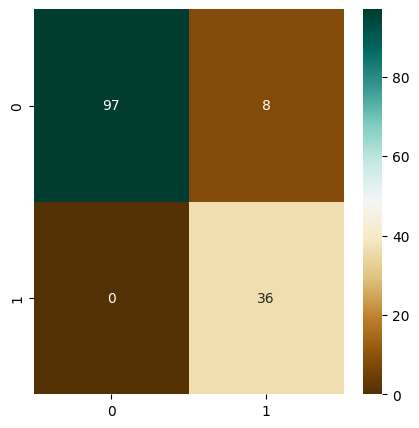

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(list(y_test), rf_clf.predict(X_test))
plt.figure(figsize = (5, 5))
sns.heatmap(cm, annot = True,fmt='g',cmap='BrBG')
print(f"Classification Report :- \n {classification_report(y_test, rf_clf.predict(X_test))}")

**SAVE THE RF MODEL**

In [41]:
import pickle
# Define the path to save the pickle file
pickle_file_path = 'C:\\Users\\Indhumathi\\asd project\\RandomForest.pkl'  # You can specify the full path or relative path

# Save the model
with open(pickle_file_path, 'wb') as file:
    pickle.dump(rf_clf, file)

print(f"Model saved to {pickle_file_path}")

Model saved to C:\Users\Indhumathi\asd project\RandomForest.pkl


**EXTREME GRADIENT BOOSTING (XGB)**

In [42]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb_clf = XGBClassifier()
xgb_clf.fit(X_train_sm,y_train_sm)
xgb_clf_acc = accuracy_score(y_test, xgb_clf.predict(X_test))
acc.append(xgb_clf_acc)
model.append('XGB')
print(f"Test Accuracy of Extreme Gradient Boosting Classifier is {xgb_clf_acc} \n")

Test Accuracy of Extreme Gradient Boosting Classifier is 0.9574468085106383 



**Classification report & confusion matrix for XGB**

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       105
           1       0.86      1.00      0.92        36

    accuracy                           0.96       141
   macro avg       0.93      0.97      0.95       141
weighted avg       0.96      0.96      0.96       141



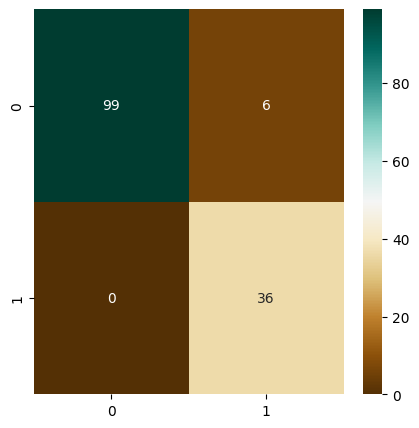

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(list(y_test), xgb_clf.predict(X_test))
plt.figure(figsize = (5, 5))
sns.heatmap(cm, annot = True,fmt='g',cmap='BrBG')
print(f"Classification Report :- \n {classification_report(y_test, xgb_clf.predict(X_test))}")

**SAVE THE XGB MODEL**

In [45]:
import pickle
# Define the path to save the pickle file
pickle_file_path = 'C:\\Users\\Indhumathi\\asd project\\XGB.pkl'  # You can specify the full path or relative path

# Save the model
with open(pickle_file_path, 'wb') as file:
    pickle.dump(xgb_clf, file)

print(f"Model saved to {pickle_file_path}")

Model saved to C:\Users\Indhumathi\asd project\XGB.pkl


**MODEL COMPARISION**

In [46]:
models = pd.DataFrame({
    'Model' : ['Random Forest','Extreme Gradient Boosting'],
    'Score' : [rf_clf_acc,xgb_clf_acc]
})


models.sort_values(by = 'Score', ascending = False)

,Model,Score
1,Extreme Gradient Boosting,0.957447
0,Random Forest,0.943262


In [47]:
pip install plotly

In [48]:
import plotly.express as px

px.bar(data_frame = models, x = 'Score', y = 'Model', color = 'Score', template = 'plotly_dark',
       title = 'Models Comparison')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'Score=%{marker.color}<br>Model=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': array([0.94326241, 0.95744681]), 'coloraxis': 'coloraxis', 'pattern': {'shape': ''}},
              'name': '',
              'offsetgroup': '',
              'orientation': 'h',
              'showlegend': False,
              'textposition': 'auto',
              'type': 'bar',
              'x': array([0.94326241, 0.95744681]),
              'xaxis': 'x',
              'y': array(['Random Forest', 'Extreme Gradient Boosting'], dtype=object),
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'coloraxis': {'colorbar': {'title': {'text': 'Score'}},
                             'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']]},
               'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Models Comparison'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Score'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Model'}}}
})

**MANUAL TESTING - ASD**

In [49]:
import os

if os.path.getsize('C:\\Users\\Indhumathi\\asd project\\RandomForest.pkl') == 0:
    print("Error: The pickle file is empty.")
else:
    print("File size is valid.")


File size is valid.


In [50]:
import os

if os.path.getsize('C:\\Users\\Indhumathi\\asd project\\XGB.pkl') == 0:
    print("Error: The pickle file is empty.")
else:
    print("File size is valid.")

File size is valid.


**TESTING - RF**

In [51]:
import pickle
import numpy as np

def load_model(file_path):
    """Load the machine learning model from a pickle file."""
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    return model

def get_user_input():
    """Prompt the user for input data."""
    # Example: Assume we need 3 features for the model
    print("Please enter the following features:")
    feature1 = float(input("A1 SCORE : "))
    feature2 = float(input("A2 SCORE : "))
    feature3 = float(input("A3 SCORE : "))
    feature4 = float(input("A4 SCORE : "))
    feature5 = float(input("A5 SCORE : "))
    feature6 = float(input("A6 SCORE : "))
    feature7 = float(input("A7 SCORE : "))
    feature8 = float(input("A8 SCORE : "))
    feature9 = float(input("A9 SCORE : "))
    feature10 = float(input("A10 SCORE : "))
    feature11 = float(input("AGE : "))
    feature12 = float(input("GENDER : "))
    feature13 = float(input("ETHNICITY : "))
    feature14 = float(input("JUNDICE : "))
    feature15 = float(input("AUSTIM : "))
    feature16 = float(input("RELATION : "))
    return np.array([[feature1, feature2, feature3, feature4, feature5, feature6, feature7, feature8, feature9, feature10, feature11, feature12, feature13, feature14, feature15, feature16]])

def make_prediction(model, user_input):
    """Make a prediction using the loaded model."""
    prediction = model.predict(user_input)
    return prediction

def main():
    # Load the trained model
    pickle_file_path = 'C:\\Users\\Indhumathi\\asd project\\RandomForest.pkl'  # Path to your pickle file
    model = load_model(pickle_file_path)

    # Get user input
    user_input = get_user_input()

    # Make prediction
    prediction = make_prediction(model, user_input)

    # Display the result
    print(f"The prediction result is: {prediction[0]}")

if __name__ == "__main__":
    main()

Please enter the following features:
The prediction result is: 0


**TESTING - XGB**

In [52]:
import pickle
import numpy as np

def load_model(file_path):
    """Load the machine learning model from a pickle file."""
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    return model

def get_user_input():
    """Prompt the user for input data."""
    # Example: Assume we need 3 features for the model
    print("Please enter the following features:")
    feature1 = float(input("A1 SCORE : "))
    feature2 = float(input("A2 SCORE : "))
    feature3 = float(input("A3 SCORE : "))
    feature4 = float(input("A4 SCORE : "))
    feature5 = float(input("A5 SCORE : "))
    feature6 = float(input("A6 SCORE : "))
    feature7 = float(input("A7 SCORE : "))
    feature8 = float(input("A8 SCORE : "))
    feature9 = float(input("A9 SCORE : "))
    feature10 = float(input("A10 SCORE : "))
    feature11 = float(input("AGE : "))
    feature12 = float(input("GENDER : "))
    feature13 = float(input("ETHNICITY : "))
    feature14 = float(input("JUNDICE : "))
    feature15 = float(input("AUSTIM : "))
    feature16 = float(input("RELATION : "))
    return np.array([[feature1, feature2, feature3, feature4, feature5, feature6, feature7, feature8, feature9, feature10, feature11, feature12, feature13, feature14, feature15, feature16]])

def make_prediction(model, user_input):
    """Make a prediction using the loaded model."""
    prediction = model.predict(user_input)
    return prediction

def main():

    pickle_file_path = 'C:\\Users\\Indhumathi\\asd project\\XGB.pkl'
    model = load_model(pickle_file_path)


    user_input = get_user_input()


    prediction = make_prediction(model, user_input)


    print(f"The prediction result is: {prediction[0]}")

if __name__ == "__main__":
    main()

Please enter the following features:
The prediction result is: 0


**THANK YOU ..!!**